In [1]:
import warnings
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

print("xgboost version:", xgb.__version__)

xgboost version: 3.2.0


In [2]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c m5-forecasting-accuracy
!unzip -o -q m5-forecasting-accuracy.zip -d data
!ls -la data

Saving kaggle.json to kaggle.json
100% 45.8M/45.8M [00:00<00:00, 180MB/s]

total 439936
drwxr-xr-x 2 root root      4096 Jun 30 14:12 .
drwxr-xr-x 1 root root      4096 Jun 30 14:12 ..
-rw-r--r-- 1 root root    103469 Jun  1  2020 calendar.csv
-rw-r--r-- 1 root root 121736518 Jun  1  2020 sales_train_evaluation.csv
-rw-r--r-- 1 root root 120007726 Jun  1  2020 sales_train_validation.csv
-rw-r--r-- 1 root root   5228786 Jun  1  2020 sample_submission.csv
-rw-r--r-- 1 root root 203395785 Jun  1  2020 sell_prices.csv


In [3]:
HORIZON = 28
SAMPLE_FRACTION = 0.05
LAGS = [28, 35, 42, 56]
ROLL_WINDOWS = [7, 14, 28]

In [4]:
def reduce_mem(df):
    for col in df.columns:
        c = df[col]
        if pd.api.types.is_integer_dtype(c):
            df[col] = pd.to_numeric(c, downcast="integer")
        elif pd.api.types.is_float_dtype(c):
            df[col] = pd.to_numeric(c, downcast="float")
    return df

calendar = pd.read_csv("data/calendar.csv")
sales    = pd.read_csv("data/sales_train_validation.csv")
prices   = pd.read_csv("data/sell_prices.csv")

if SAMPLE_FRACTION < 1.0:
    keep = sales["id"].sample(frac=SAMPLE_FRACTION, random_state=0)
    sales = sales[sales["id"].isin(keep)]

print("sales:", sales.shape, "| calendar:", calendar.shape, "| prices:", prices.shape)

sales: (1524, 1919) | calendar: (1969, 14) | prices: (6841121, 4)


In [5]:
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]

df = sales.melt(id_vars=id_cols, value_vars=day_cols, var_name="d", value_name="sales")
df = df.merge(calendar, on="d", how="left")
df = df.merge(prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")

df["d_int"] = df["d"].str.replace("d_", "", regex=False).astype("int32")
df["date"]  = pd.to_datetime(df["date"])
df = reduce_mem(df)
print("long table:", df.shape)
df.head()

long table: (2915412, 23)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price,d_int
0,HOBBIES_1_019_CA_1_validation,HOBBIES_1_019,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,1
1,HOBBIES_1_068_CA_1_validation,HOBBIES_1_068,HOBBIES_1,HOBBIES,CA_1,CA,d_1,1,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,6.84,1
2,HOBBIES_1_103_CA_1_validation,HOBBIES_1_103,HOBBIES_1,HOBBIES,CA_1,CA,d_1,25,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,0.70,1
3,HOBBIES_1_127_CA_1_validation,HOBBIES_1_127,HOBBIES_1,HOBBIES,CA_1,CA,d_1,1,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,1.00,1
4,HOBBIES_1_156_CA_1_validation,HOBBIES_1_156,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,2011,NaN,NaN,NaN,NaN,0,0,0,NaN,1


In [6]:
df = df.sort_values(["id", "d_int"]).reset_index(drop=True)
grp = df.groupby("id")["sales"]


for lag in LAGS:
    df[f"lag_{lag}"] = grp.shift(lag)


for w in ROLL_WINDOWS:
    df[f"roll_mean_{w}"] = grp.transform(lambda s: s.shift(HORIZON).rolling(w).mean())
    df[f"roll_std_{w}"]  = grp.transform(lambda s: s.shift(HORIZON).rolling(w).std())


pg = df.groupby(["store_id", "item_id"])["sell_price"]
df["price_change"] = pg.pct_change()
df["price_norm"]   = df["sell_price"] / pg.transform("mean")


df["day_of_month"] = df["date"].dt.day
df["week_of_year"] = df["date"].dt.isocalendar().week.astype("int32")
df["has_event"]    = df["event_name_1"].notna().astype("int8")


df["snap"] = 0
for st in ["CA", "TX", "WI"]:
    col = f"snap_{st}"
    if col in df.columns:
        mask = df["state_id"] == st
        df.loc[mask, "snap"] = df.loc[mask, col].fillna(0).astype("int8")


cat_cols = ["item_id", "dept_id", "cat_id", "store_id", "state_id",
            "event_name_1", "event_type_1"]
for c in cat_cols:
    df[c + "_enc"] = df[c].astype("category").cat.codes.astype("int32")

print("features built")

features built


In [7]:
feats = (
    [f"lag_{l}" for l in LAGS]
    + [f"roll_mean_{w}" for w in ROLL_WINDOWS]
    + [f"roll_std_{w}" for w in ROLL_WINDOWS]
    + ["sell_price", "price_change", "price_norm",
       "wday", "month", "year", "day_of_month", "week_of_year", "has_event", "snap"]
    + [c + "_enc" for c in cat_cols]
)
feats = [c for c in feats if c in df.columns]

last_day = df["d_int"].max()
valid_start = last_day - HORIZON + 1
train = df[df["d_int"] < valid_start].copy()
valid = df[df["d_int"] >= valid_start].copy()

#
train = train.dropna(subset=[f"lag_{max(LAGS)}"])
print(f"train rows: {len(train):,} | valid rows: {len(valid):,} | features: {len(feats)}")

train rows: 2,787,396 | valid rows: 42,672 | features: 27


In [8]:

last_week = df[(df["d_int"] >= valid_start - 7) & (df["d_int"] < valid_start)][["id", "d_int", "sales"]].copy()
last_week["pos"] = last_week["d_int"] - (valid_start - 7)     # 0..6
last_week = last_week.rename(columns={"sales": "snaive"})[["id", "pos", "snaive"]]

valid = valid.copy()
valid["pos"] = (valid["d_int"] - valid_start) % 7
valid = valid.merge(last_week, on=["id", "pos"], how="left")
valid["snaive"] = valid["snaive"].fillna(0)

def rmse(y, p):
    y, p = np.asarray(y), np.asarray(p)
    return float(np.sqrt(np.mean((y - p) ** 2)))

def rmsse(train_df, valid_df, pred):
    vd = valid_df.copy(); vd["pred"] = pred
    naive_err = (train_df.sort_values(["id", "d_int"]).groupby("id")["sales"]
                 .apply(lambda s: np.mean(np.diff(s.values) ** 2) if len(s) > 1 else np.nan))
    scores = []
    for sid, g in vd.groupby("id"):
        d = naive_err.get(sid, np.nan)
        if d and d > 0:
            scores.append(np.sqrt(np.mean((g["sales"].values - g["pred"].values) ** 2) / d))
    return float(np.mean(scores)) if scores else float("nan")

In [9]:
dtrain = xgb.DMatrix(train[feats], label=train["sales"])
dvalid = xgb.DMatrix(valid[feats], label=valid["sales"])

params = {
    "objective": "reg:tweedie",
    "tweedie_variance_power": 1.1,
    "eval_metric": "rmse",
    "tree_method": "hist",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 5,
    "lambda": 1.0,
    "seed": 0,
}

model = xgb.train(
    params, dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dvalid, "valid")],
    early_stopping_rounds=50,
    verbose_eval=100,
)

[0]	train-rmse:5.13483	valid-rmse:3.92409
[100]	train-rmse:2.64562	valid-rmse:2.04798
[200]	train-rmse:2.50131	valid-rmse:2.01255
[253]	train-rmse:2.43804	valid-rmse:2.01854


In [10]:
xgb_pred  = np.clip(model.predict(dvalid), 0, None)
base_pred = valid["snaive"].values

print(f"{'Model':<18}{'RMSE':>10}{'RMSSE':>12}")
print("-" * 40)
print(f"{'Seasonal-naive':<18}{rmse(valid['sales'], base_pred):>10.4f}{rmsse(train, valid, base_pred):>12.4f}")
print(f"{'XGBoost':<18}{rmse(valid['sales'], xgb_pred):>10.4f}{rmsse(train, valid, xgb_pred):>12.4f}")

lift = 100 * (1 - rmse(valid['sales'], xgb_pred) / rmse(valid['sales'], base_pred))
print(f"\nXGBoost beats the baseline by {lift:.1f}% on RMSE.")

Model                   RMSE       RMSSE
----------------------------------------
Seasonal-naive        2.7203      1.1424
XGBoost               2.0185      0.8888

XGBoost beats the baseline by 25.8% on RMSE.


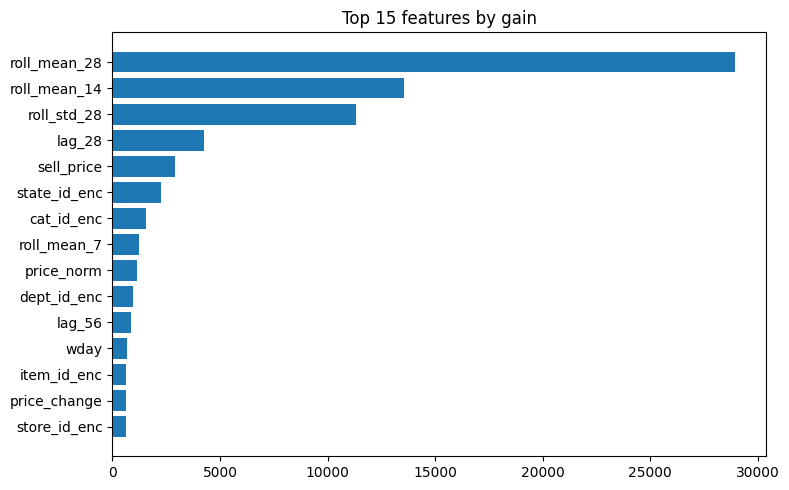

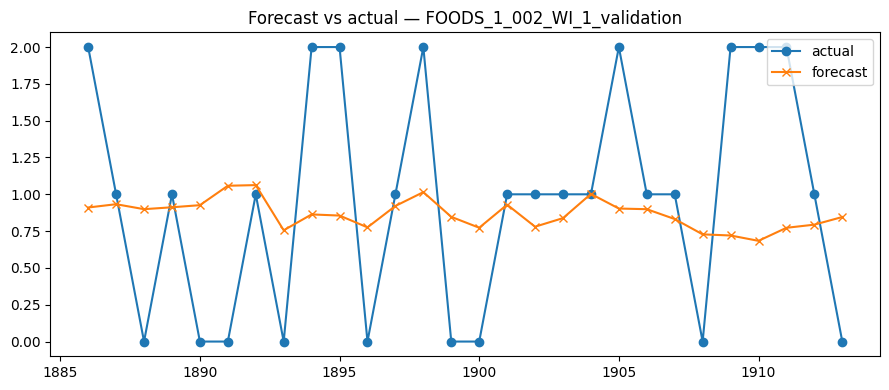

In [11]:

imp = model.get_score(importance_type="gain")
imp = dict(sorted(imp.items(), key=lambda x: x[1], reverse=True)[:15])
plt.figure(figsize=(8, 5))
plt.barh(list(imp.keys())[::-1], list(imp.values())[::-1])
plt.title("Top 15 features by gain"); plt.tight_layout(); plt.show()


ex = valid["id"].iloc[0]
v = valid[valid["id"] == ex].sort_values("d_int")
vp = np.clip(model.predict(xgb.DMatrix(v[feats])), 0, None)
plt.figure(figsize=(9, 4))
plt.plot(v["d_int"], v["sales"].values, marker="o", label="actual")
plt.plot(v["d_int"], vp, marker="x", label="forecast")
plt.title(f"Forecast vs actual — {ex}"); plt.legend(); plt.tight_layout(); plt.show()